# Lecture 2: Risk Aversion, Utility, Portfolio Choice, and the Capital Market Line

These notes build on the first lecture on returns, compounding, return statistics, and risk measurement.

The goal of this lecture is to explain **why investors hold different portfolios** even when they face the same menu of assets. The answer is that investors differ in their **risk aversion**, wealth, investment horizon, borrowing opportunities, tax circumstances, and background risks. In the simplest textbook model, investors differ mainly by their risk-aversion parameter.

We proceed in a sequence:

1. Utility and risk aversion.
2. Certainty equivalents and certainty-equivalent rates.
3. Mean-variance preferences and indifference curves.
4. Portfolio weights and portfolios of portfolios.
5. One risky asset and one risk-free asset.
6. The capital allocation line.
7. The Sharpe ratio.
8. Leverage, margin, and higher borrowing rates.
9. Utility maximization and tangency.
10. The market portfolio, passive diversification, and the capital market line.
11. Inferring the representative investor's risk-aversion parameter.

## 1. Why Utility Appears in Investment Analysis

An investment is not desirable merely because it has a high expected return. A lottery with a high average payoff may still be unattractive if it exposes the investor to large losses in states where wealth is especially valuable.

Therefore, portfolio choice begins with the investor's utility from wealth or consumption.

Let terminal wealth be \( W_1 \). The investor evaluates uncertain wealth using expected utility:

$$
\mathbb{E}[U(W_1)].
$$

The investor is **risk averse** if the utility function is concave:

$$
U'(W) > 0,
$$

$$
U''(W) < 0.
$$

The first condition means more wealth is preferred to less. The second means marginal utility declines as wealth rises.

Concavity captures the idea that losing \( \$1{,}000 \) hurts more when wealth is low than gaining \( \$1{,}000 \) helps when wealth is high.

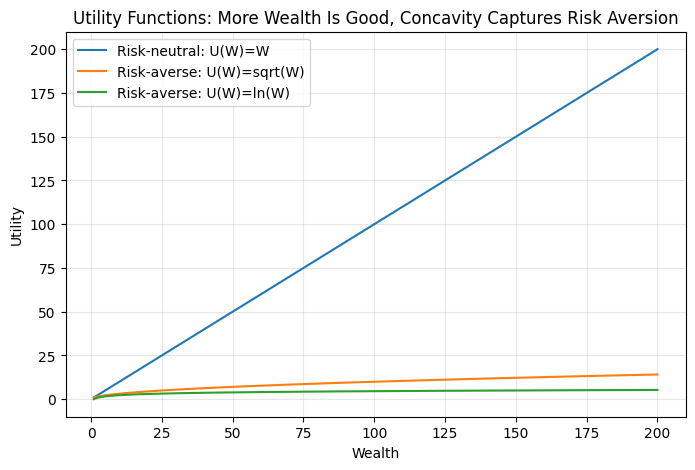

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)

# Simple wealth grid
W = np.linspace(1, 200, 500)

def U_log(W):
    return np.log(W)

def U_sqrt(W):
    return np.sqrt(W)

def U_linear(W):
    return W

plt.figure(figsize=(8, 5))
plt.plot(W, U_linear(W), label="Risk-neutral: U(W)=W")
plt.plot(W, U_sqrt(W), label="Risk-averse: U(W)=sqrt(W)")
plt.plot(W, U_log(W), label="Risk-averse: U(W)=ln(W)")
plt.title("Utility Functions: More Wealth Is Good, Concavity Captures Risk Aversion")
plt.xlabel("Wealth")
plt.ylabel("Utility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The linear investor is risk-neutral. The concave investors are risk-averse.

A risk-neutral investor cares only about expected wealth:

$$
\mathbb{E}[W_1].
$$

A risk-averse investor cares about the distribution of wealth:

$$
\mathbb{E}[U(W_1)].
$$

Because \( U \) is concave, Jensen's inequality implies:

$$
U(\mathbb{E}[W_1]) > \mathbb{E}[U(W_1)]
$$

for a genuinely risky payoff. The utility of expected wealth exceeds the expected utility of risky wealth.

## 2. Common Utility Functions

Investment theory uses several convenient utility functions. Each makes a different assumption about how risk aversion behaves as wealth changes.

### 2.1 Mean-Variance Utility

Mean-variance utility is usually written as:

$$
U = \mathbb{E}[R] - \frac{A}{2}\sigma^2.
$$

Here:

- \( \mathbb{E}[R] \) is expected return,
- \( \sigma^2 \) is return variance,
- \( A \) is the coefficient of risk aversion.

Higher \( A \) means the investor dislikes variance more strongly.

Mean-variance utility is not a primitive utility function over consumption in the same way as log, CRRA, or CARA utility. It is often used as an approximation or as an exact representation under special assumptions, such as normally distributed returns and quadratic utility.

Still, it is extremely useful for teaching portfolio choice.

### 2.2 Time-Separable Log Utility

A time-separable expected utility investor has preferences such as:

$$
U = u(C_0) + \beta \mathbb{E}[u(C_1)].
$$

With log utility:

$$
u(C) = \ln(C).
$$

The marginal utility of consumption is:

$$
u'(C) = \frac{1}{C}.
$$

The stochastic discount factor is:

$$
M_1 = \beta \frac{u'(C_1)}{u'(C_0)}
= \beta \frac{C_0}{C_1}.
$$

Log utility is a special case of CRRA utility with relative risk aversion equal to 1.

### 2.3 CRRA Utility

CRRA stands for **constant relative risk aversion**.

For \( \gamma \neq 1 \), CRRA utility is:

$$
u(W) = \frac{W^{1-\gamma}}{1-\gamma}.
$$

For \( \gamma = 1 \), it becomes log utility:

$$
u(W) = \ln(W).
$$

The coefficient of relative risk aversion is:

$$
RRA(W) = -\frac{W u''(W)}{u'(W)} = \gamma.
$$

The coefficient is constant, which is why the function is called constant relative risk aversion.

A CRRA investor generally invests a roughly constant fraction of wealth in risky assets as wealth changes.

### 2.4 CARA Utility

CARA stands for **constant absolute risk aversion**.

A common CARA utility function is:

$$
u(W) = -e^{-aW}.
$$

Absolute risk aversion is:

$$
ARA(W) = -\frac{u''(W)}{u'(W)} = a.
$$

The coefficient is constant.

CARA utility often implies that the dollar amount invested in risky assets is independent of wealth. That can be mathematically convenient but is often less plausible for long-horizon portfolio choice than CRRA preferences.

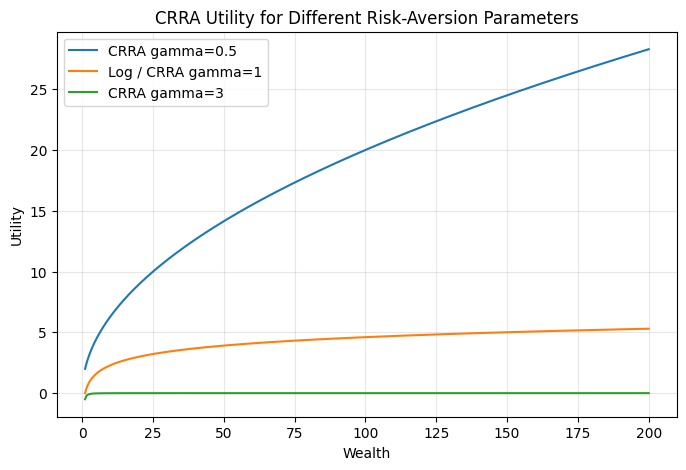

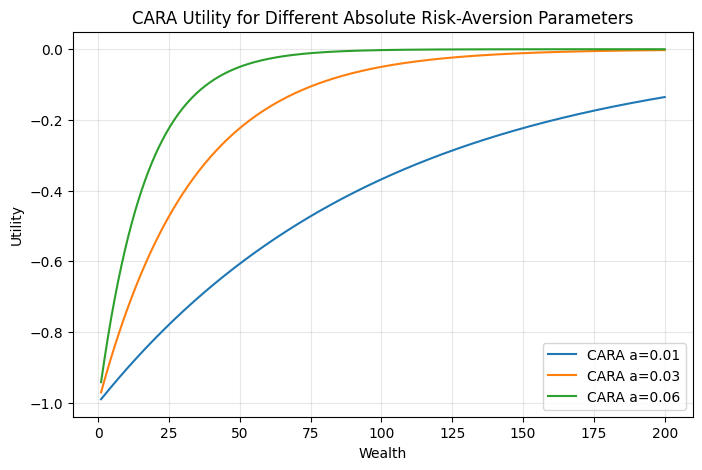

In [2]:
# Compare utility curvature across log, CRRA, and CARA utility functions
W = np.linspace(1, 200, 500)

def U_crra(W, gamma):
    W = np.asarray(W, dtype=float)
    if gamma == 1:
        return np.log(W)
    return (W ** (1 - gamma)) / (1 - gamma)

def U_cara(W, a):
    return -np.exp(-a * W)

plt.figure(figsize=(8, 5))
plt.plot(W, U_crra(W, gamma=0.5), label="CRRA gamma=0.5")
plt.plot(W, U_crra(W, gamma=1.0), label="Log / CRRA gamma=1")
plt.plot(W, U_crra(W, gamma=3.0), label="CRRA gamma=3")
plt.title("CRRA Utility for Different Risk-Aversion Parameters")
plt.xlabel("Wealth")
plt.ylabel("Utility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(W, U_cara(W, a=0.01), label="CARA a=0.01")
plt.plot(W, U_cara(W, a=0.03), label="CARA a=0.03")
plt.plot(W, U_cara(W, a=0.06), label="CARA a=0.06")
plt.title("CARA Utility for Different Absolute Risk-Aversion Parameters")
plt.xlabel("Wealth")
plt.ylabel("Utility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Absolute and Relative Risk Aversion

Two measures are especially important.

Absolute risk aversion:

$$
ARA(W) = -\frac{U''(W)}{U'(W)}.
$$

Relative risk aversion:

$$
RRA(W) = -\frac{W U''(W)}{U'(W)}.
$$

Absolute risk aversion governs how the investor responds to a fixed-dollar gamble.

Relative risk aversion governs how the investor responds to a gamble scaled by wealth.

For CRRA utility:

$$
RRA(W) = \gamma.
$$

For CARA utility:

$$
ARA(W) = a.
$$

In [3]:
# Numerical derivatives to show absolute and relative risk aversion
def numerical_derivatives(f, x, h=1e-4):
    f1 = (f(x + h) - f(x - h)) / (2 * h)
    f2 = (f(x + h) - 2 * f(x) + f(x - h)) / (h ** 2)
    return f1, f2

wealth_points = np.array([10, 25, 50, 100, 200], dtype=float)

rows = []
for W0 in wealth_points:
    f_crra = lambda x: U_crra(x, gamma=3.0)
    f_cara = lambda x: U_cara(x, a=0.03)

    u1, u2 = numerical_derivatives(f_crra, W0)
    ara_crra = -u2 / u1
    rra_crra = -W0 * u2 / u1

    u1, u2 = numerical_derivatives(f_cara, W0)
    ara_cara = -u2 / u1
    rra_cara = -W0 * u2 / u1

    rows.append({
        "Wealth": W0,
        "CRRA ARA": ara_crra,
        "CRRA RRA": rra_crra,
        "CARA ARA": ara_cara,
        "CARA RRA": rra_cara
    })

risk_aversion_table = pd.DataFrame(rows)
risk_aversion_table

,Wealth,CRRA ARA,CRRA RRA,CARA ARA,CARA RRA
0,10.0,0.300000,3.000000,0.030000,0.300004
1,25.0,0.120000,2.999996,0.030000,0.750004
2,50.0,0.060000,2.999987,0.030001,1.500041
3,100.0,0.029999,2.999920,0.030001,3.000109
4,200.0,0.014999,2.999716,0.030003,6.000522


The table illustrates the difference between CRRA and CARA preferences.

For CRRA utility, relative risk aversion is approximately constant. Absolute risk aversion declines as wealth rises.

For CARA utility, absolute risk aversion is approximately constant. Relative risk aversion rises with wealth.

These distinctions matter because portfolio choice is affected not merely by expected return and volatility, but also by how the investor's risk tolerance changes with wealth.

## 4. Certainty Equivalents

The **certainty equivalent** is the sure amount of wealth that gives the investor the same utility as a risky payoff.

For a risky payoff \( W_1 \), the certainty equivalent \( CE \) solves:

$$
U(CE) = \mathbb{E}[U(W_1)].
$$

For a risk-averse investor:

$$
CE < \mathbb{E}[W_1].
$$

The difference between expected wealth and the certainty equivalent is the **risk premium** the investor would pay to avoid the risk:

$$
\text{Risk Premium} = \mathbb{E}[W_1] - CE.
$$

The certainty-equivalent rate is the guaranteed return that gives the same utility as the risky investment.

In [4]:
# Certainty equivalent for a two-state gamble
W0 = 100
payoffs = np.array([80, 130])
probs = np.array([0.5, 0.5])

def CE_crra(payoffs, probs, gamma):
    expected_utility = np.sum(probs * U_crra(payoffs, gamma))
    if gamma == 1:
        return np.exp(expected_utility)
    return ((1 - gamma) * expected_utility) ** (1 / (1 - gamma))

gammas = [0.5, 1, 2, 5, 10]
rows = []
for gamma in gammas:
    ce = CE_crra(payoffs, probs, gamma)
    rows.append({
        "gamma": gamma,
        "Expected Wealth": np.sum(probs * payoffs),
        "Certainty Equivalent": ce,
        "Risk Premium Paid to Avoid Gamble": np.sum(probs * payoffs) - ce,
        "Certainty Equivalent Rate": ce / W0 - 1
    })

ce_table = pd.DataFrame(rows)
ce_table

,gamma,Expected Wealth,Certainty Equivalent,Risk Premium Paid to Avoid Gamble,Certainty Equivalent Rate
0,0.5,105.0,103.490195,1.509805,0.034902
1,1.0,105.0,101.980390,3.019610,0.019804
2,2.0,105.0,99.047619,5.952381,-0.009524
3,5.0,105.0,92.001894,12.998106,-0.079981
4,10.0,105.0,86.284115,18.715885,-0.137159


The certainty equivalent falls as risk aversion rises.

The expected payoff of the gamble is the same for all investors, but the subjective value of the gamble is not. More risk-averse investors require more compensation for bearing the same risk.

## 5. Mean-Variance Utility and Certainty-Equivalent Returns

In the mean-variance setting, utility is often written:

$$
U = \mathbb{E}[R] - \frac{A}{2}\sigma^2.
$$

This utility value can be interpreted as a certainty-equivalent return:

$$
R_{CE} = \mathbb{E}[R] - \frac{A}{2}\sigma^2.
$$

The risk penalty is:

$$
\frac{A}{2}\sigma^2.
$$

For the same expected return and volatility, investors with higher \( A \) assign a lower certainty-equivalent return.

In [5]:
# Mean-variance certainty-equivalent return
mu = 0.10
sigma = 0.20
A_values = np.array([1, 2, 3, 4, 5, 8, 10])

mv_ce = pd.DataFrame({
    "Risk Aversion A": A_values,
    "Expected Return": mu,
    "Standard Deviation": sigma,
    "Variance": sigma**2,
    "Certainty-Equivalent Return": mu - 0.5 * A_values * sigma**2
})

mv_ce

,Risk Aversion A,Expected Return,Standard Deviation,Variance,Certainty-Equivalent Return
0,1,0.1,0.2,0.04,8.000000e-02
1,2,0.1,0.2,0.04,6.000000e-02
2,3,0.1,0.2,0.04,4.000000e-02
3,4,0.1,0.2,0.04,2.000000e-02
4,5,0.1,0.2,0.04,-1.387779e-17
5,8,0.1,0.2,0.04,-6.000000e-02
6,10,0.1,0.2,0.04,-1.000000e-01


This is the simplest way to connect utility, expected return, variance, and portfolio choice.

A high-volatility asset may have a high expected return, but its certainty-equivalent return may still be low for a risk-averse investor.

## 6. Indifference Curves in the Mean-Standard Deviation Plane

An indifference curve shows combinations of expected return and standard deviation that deliver the same utility.

Start with:

$$
U = \mu - \frac{A}{2}\sigma^2.
$$

Holding \( U \) constant gives:

$$
\mu = U + \frac{A}{2}\sigma^2.
$$

In the \( (\sigma, \mu) \) plane, indifference curves slope upward. Investors require higher expected return to accept higher standard deviation.

Higher \( A \) makes the curve steeper. More risk-averse investors require more compensation for the same increase in risk.

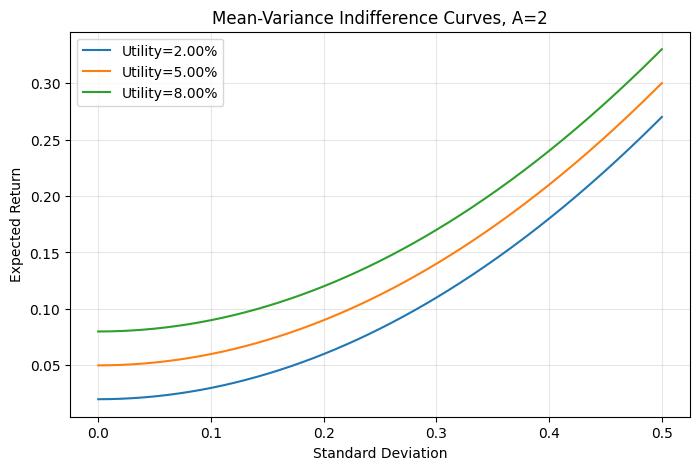

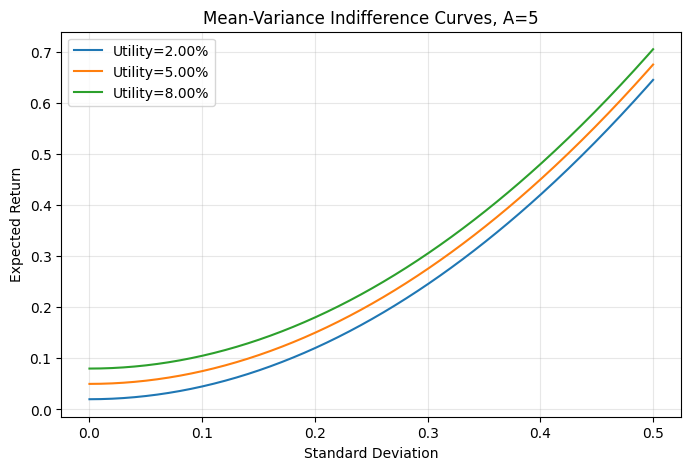

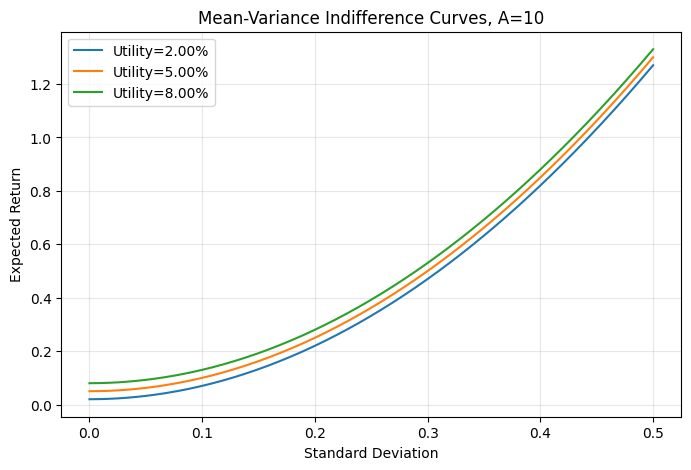

In [6]:
sigma_grid = np.linspace(0, 0.5, 300)
utility_levels = [0.02, 0.05, 0.08]
A_list = [2, 5, 10]

for A in A_list:
    plt.figure(figsize=(8, 5))
    for U_level in utility_levels:
        mu_curve = U_level + 0.5 * A * sigma_grid**2
        plt.plot(sigma_grid, mu_curve, label=f"Utility={U_level:.2%}")
    plt.title(f"Mean-Variance Indifference Curves, A={A}")
    plt.xlabel("Standard Deviation")
    plt.ylabel("Expected Return")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Each graph holds risk aversion fixed and plots several utility levels. Higher curves are preferred to lower curves because they provide more expected return for a given level of risk.

Comparing across graphs shows how risk aversion changes the slope. A highly risk-averse investor has steep indifference curves.

## 7. Portfolio Weights

A portfolio is a weighted average of assets.

If a portfolio holds \( N \) assets and the weight on asset \( i \) is \( w_i \), then:

$$
\sum_{i=1}^N w_i = 1.
$$

The expected return of the portfolio is:

$$
\mathbb{E}[R_p] = \sum_{i=1}^N w_i \mathbb{E}[R_i].
$$

In vector notation:

$$
\mu_p = w' \mu.
$$

Portfolio variance is:

$$
\sigma_p^2 = w' \Sigma w,
$$

where \( \Sigma \) is the covariance matrix of asset returns.

For two risky assets:

$$
\sigma_p^2
=
w_1^2 \sigma_1^2
+
w_2^2 \sigma_2^2
+
2w_1w_2\sigma_{12}.
$$

The covariance term is the source of diversification.

In [7]:
# Two-asset portfolio illustration
mu1, mu2 = 0.08, 0.14
sigma1, sigma2 = 0.12, 0.25
rho = 0.25
cov12 = rho * sigma1 * sigma2

weights = np.linspace(0, 1, 101)
rows = []
for w1 in weights:
    w2 = 1 - w1
    mu_p = w1 * mu1 + w2 * mu2
    var_p = w1**2 * sigma1**2 + w2**2 * sigma2**2 + 2*w1*w2*cov12
    rows.append({"Weight in Asset 1": w1, "Weight in Asset 2": w2, "Expected Return": mu_p, "Standard Deviation": np.sqrt(var_p)})

two_asset = pd.DataFrame(rows)
two_asset.head()

,Weight in Asset 1,Weight in Asset 2,Expected Return,Standard Deviation
0,0.00,1.00,0.1400,0.250000
1,0.01,0.99,0.1394,0.247803
2,0.02,0.98,0.1388,0.245611
3,0.03,0.97,0.1382,0.243425
4,0.04,0.96,0.1376,0.241245


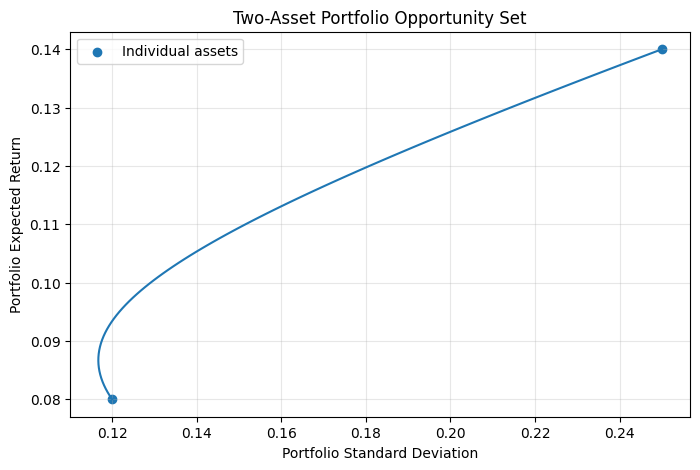

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(two_asset["Standard Deviation"], two_asset["Expected Return"])
plt.scatter([sigma1, sigma2], [mu1, mu2], label="Individual assets")
plt.title("Two-Asset Portfolio Opportunity Set")
plt.xlabel("Portfolio Standard Deviation")
plt.ylabel("Portfolio Expected Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The portfolio curve bends because risk is not a weighted average of individual standard deviations. Risk depends on covariance.

If the assets are imperfectly correlated, combining them can reduce risk without proportionately reducing expected return.

## 8. Portfolios of Portfolios

If Portfolio A has return \( R_A \), Portfolio B has return \( R_B \), and an investor places weight \( y \) in Portfolio A and \( 1-y \) in Portfolio B, then:

$$
R_p = yR_A + (1-y)R_B.
$$

The expected return is:

$$
\mu_p = y\mu_A + (1-y)\mu_B.
$$

The variance is:

$$
\sigma_p^2
=
y^2\sigma_A^2
+
(1-y)^2\sigma_B^2
+
2y(1-y)\sigma_{AB}.
$$

A portfolio can therefore be treated as an asset. This is why investors can combine mutual funds, ETFs, or managed portfolios using the same portfolio mathematics.

In [9]:
# Simulate three assets, build two portfolios, then combine the portfolios
n = 120
means = np.array([0.006, 0.008, 0.004])
vols = np.array([0.04, 0.06, 0.03])
corr = np.array([
    [1.00, 0.35, 0.10],
    [0.35, 1.00, 0.20],
    [0.10, 0.20, 1.00]
])
cov = np.outer(vols, vols) * corr

returns = rng.multivariate_normal(means, cov, size=n)
returns_df = pd.DataFrame(returns, columns=["Asset A", "Asset B", "Asset C"])

portfolio_1_weights = np.array([0.60, 0.40, 0.00])
portfolio_2_weights = np.array([0.10, 0.20, 0.70])

returns_df["Portfolio 1"] = returns_df[["Asset A", "Asset B", "Asset C"]].values @ portfolio_1_weights
returns_df["Portfolio 2"] = returns_df[["Asset A", "Asset B", "Asset C"]].values @ portfolio_2_weights
returns_df["50/50 Portfolio of Portfolios"] = 0.5 * returns_df["Portfolio 1"] + 0.5 * returns_df["Portfolio 2"]

returns_df[["Portfolio 1", "Portfolio 2", "50/50 Portfolio of Portfolios"]].agg(["mean", "std"])

,Portfolio 1,Portfolio 2,50/50 Portfolio of Portfolios
mean,0.005778,0.003773,0.004775
std,0.037364,0.025241,0.028679


Portfolio math is recursive. Once a bundle of assets is formed, it can be treated as a single risky asset in a larger portfolio.

## 9. The Risk-Free Asset

A risk-free asset has a certain return over the investment horizon.

Let its return be:

$$
R_f.
$$

Its standard deviation is:

$$
\sigma_f = 0.
$$

Its covariance with every risky asset is also zero:

$$
\operatorname{Cov}(R_f, R_i)=0.
$$

A short-term Treasury bill is often used as an empirical proxy for the risk-free asset, though in practice no asset is perfectly risk-free for every investor over every horizon.

## 10. One Risk-Free Asset and One Risky Asset

Suppose an investor allocates fraction \( y \) to a risky asset and fraction \( 1-y \) to the risk-free asset.

The portfolio return is:

$$
R_p = yR_r + (1-y)R_f.
$$

The expected return is:

$$
\mathbb{E}[R_p]
=
y\mathbb{E}[R_r] + (1-y)R_f.
$$

Equivalently:

$$
\mathbb{E}[R_p]
=
R_f + y(\mathbb{E}[R_r] - R_f).
$$

The portfolio standard deviation is:

$$
\sigma_p = |y|\sigma_r.
$$

If \( 0 \leq y \leq 1 \), the investor splits wealth between the risky asset and the risk-free asset.

If \( y > 1 \), the investor borrows at the risk-free rate and leverages the risky asset.

If \( y < 0 \), the investor shorts the risky asset and invests more than 100% in the risk-free asset.

In [10]:
Rf = 0.03
mu_risky = 0.11
sigma_risky = 0.18

y_grid = np.linspace(-0.5, 1.8, 200)
mu_p = Rf + y_grid * (mu_risky - Rf)
sigma_p = np.abs(y_grid) * sigma_risky

cal_df = pd.DataFrame({
    "Weight in Risky Asset": y_grid,
    "Expected Portfolio Return": mu_p,
    "Portfolio Standard Deviation": sigma_p
})
cal_df.head()

,Weight in Risky Asset,Expected Portfolio Return,Portfolio Standard Deviation
0,-0.500000,-0.010000,0.090000
1,-0.488442,-0.009075,0.087920
2,-0.476884,-0.008151,0.085839
3,-0.465327,-0.007226,0.083759
4,-0.453769,-0.006302,0.081678


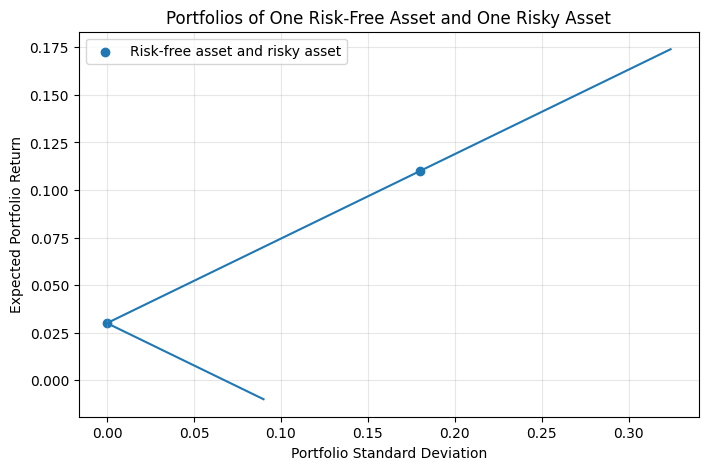

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(sigma_p, mu_p)
plt.scatter([0, sigma_risky], [Rf, mu_risky], label="Risk-free asset and risky asset")
plt.title("Portfolios of One Risk-Free Asset and One Risky Asset")
plt.xlabel("Portfolio Standard Deviation")
plt.ylabel("Expected Portfolio Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The relationship between expected return and standard deviation is linear because the risk-free asset has zero variance and zero covariance with the risky asset.

This line is the simplest version of the **capital allocation line**.

## 11. The Capital Allocation Line

The **capital allocation line**, or CAL, shows all combinations of a risk-free asset and a risky portfolio.

Let \( P \) be the risky portfolio. Then:

$$
\mathbb{E}[R_c] = R_f + y(\mathbb{E}[R_P] - R_f),
$$

and:

$$
\sigma_c = y\sigma_P
$$

for \( y \geq 0 \).

Solving for \( y \):

$$
y = \frac{\sigma_c}{\sigma_P}.
$$

Substitute into expected return:

$$
\mathbb{E}[R_c]
=
R_f
+
\frac{\mathbb{E}[R_P]-R_f}{\sigma_P}
\sigma_c.
$$

The slope of the CAL is:

$$
\frac{\mathbb{E}[R_P]-R_f}{\sigma_P}.
$$

That slope is the Sharpe ratio.

## 12. The Sharpe Ratio

The Sharpe ratio is:

$$
S_P = \frac{\mathbb{E}[R_P]-R_f}{\sigma_P}.
$$

It measures excess return per unit of total risk.

A higher Sharpe ratio means the risky portfolio offers a better tradeoff between reward and risk.

For investors who can borrow and lend at the risk-free rate, the best risky portfolio is the one with the highest Sharpe ratio.

In [12]:
candidate_portfolios = pd.DataFrame({
    "Portfolio": ["Conservative", "Balanced", "Growth", "Aggressive"],
    "Expected Return": [0.07, 0.09, 0.11, 0.14],
    "Standard Deviation": [0.08, 0.12, 0.18, 0.28]
})
candidate_portfolios["Sharpe Ratio"] = (candidate_portfolios["Expected Return"] - Rf) / candidate_portfolios["Standard Deviation"]
candidate_portfolios.sort_values("Sharpe Ratio", ascending=False)

,Portfolio,Expected Return,Standard Deviation,Sharpe Ratio
0,Conservative,0.07,0.08,0.500000
1,Balanced,0.09,0.12,0.500000
2,Growth,0.11,0.18,0.444444
3,Aggressive,0.14,0.28,0.392857


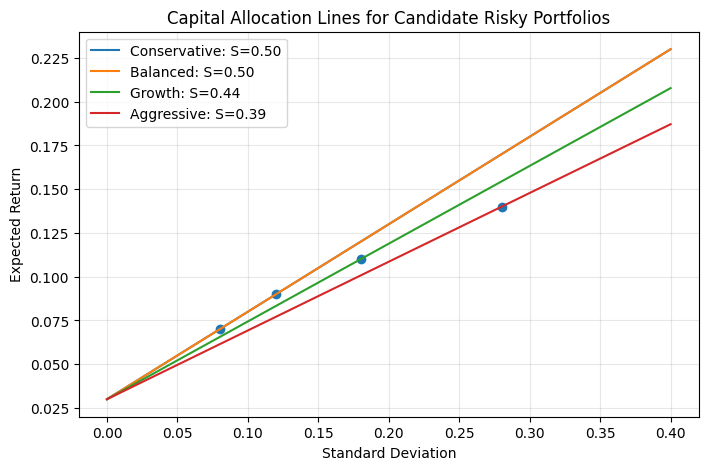

In [13]:
plt.figure(figsize=(8, 5))
for _, row in candidate_portfolios.iterrows():
    sigma_line = np.linspace(0, 0.4, 100)
    mu_line = Rf + row["Sharpe Ratio"] * sigma_line
    plt.plot(sigma_line, mu_line, label=f'{row["Portfolio"]}: S={row["Sharpe Ratio"]:.2f}')
plt.scatter(candidate_portfolios["Standard Deviation"], candidate_portfolios["Expected Return"])
plt.title("Capital Allocation Lines for Candidate Risky Portfolios")
plt.xlabel("Standard Deviation")
plt.ylabel("Expected Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The portfolio with the steepest CAL dominates the others for investors who can freely combine it with the risk-free asset. A steeper line means more expected return for each unit of standard deviation.

## 13. Utility Maximization Along the CAL

Suppose the investor uses mean-variance utility:

$$
U = \mathbb{E}[R_c] - \frac{A}{2}\sigma_c^2.
$$

For a portfolio with weight \( y \) in risky portfolio \( P \):

$$
\mathbb{E}[R_c] = R_f + y(\mathbb{E}[R_P]-R_f),
$$

and:

$$
\sigma_c^2 = y^2\sigma_P^2.
$$

Substitute into utility:

$$
U(y)
=
R_f + y(\mathbb{E}[R_P]-R_f)
-
\frac{A}{2}y^2\sigma_P^2.
$$

Differentiate with respect to \( y \):

$$
\frac{dU}{dy}
=
\mathbb{E}[R_P]-R_f
-
A y \sigma_P^2.
$$

Set equal to zero:

$$
\mathbb{E}[R_P]-R_f
=
A y^* \sigma_P^2.
$$

The optimal risky-asset weight is:

$$
y^*
=
\frac{\mathbb{E}[R_P]-R_f}{A\sigma_P^2}.
$$

Investors with lower \( A \) hold more of the risky portfolio. Investors with higher \( A \) hold less.

In [14]:
A_values = np.array([1, 2, 3, 4, 5, 8, 10])
y_star = (mu_risky - Rf) / (A_values * sigma_risky**2)

optimal_allocations = pd.DataFrame({
    "Risk Aversion A": A_values,
    "Optimal Weight in Risky Asset": y_star,
    "Weight in Risk-Free Asset": 1 - y_star,
    "Expected Portfolio Return": Rf + y_star * (mu_risky - Rf),
    "Portfolio Standard Deviation": np.abs(y_star) * sigma_risky
})
optimal_allocations

,Risk Aversion A,Optimal Weight in Risky Asset,Weight in Risk-Free Asset,Expected Portfolio Return,Portfolio Standard Deviation
0,1,2.469136,-1.469136,0.227531,0.444444
1,2,1.234568,-0.234568,0.128765,0.222222
2,3,0.823045,0.176955,0.095844,0.148148
3,4,0.617284,0.382716,0.079383,0.111111
4,5,0.493827,0.506173,0.069506,0.088889
5,8,0.308642,0.691358,0.054691,0.055556
6,10,0.246914,0.753086,0.049753,0.044444


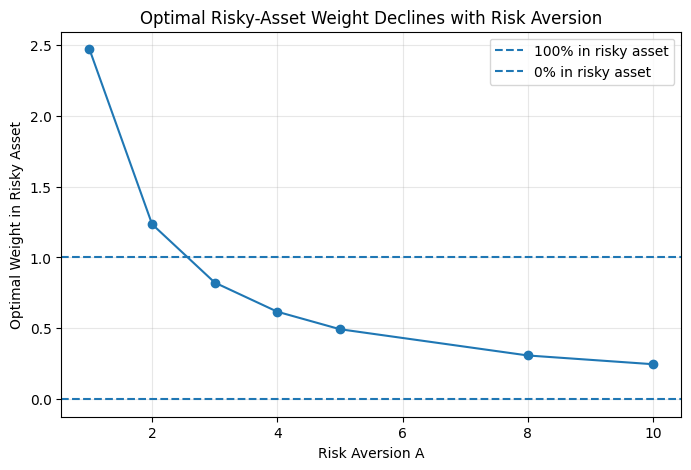

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(optimal_allocations["Risk Aversion A"], optimal_allocations["Optimal Weight in Risky Asset"], marker="o")
plt.axhline(1, linestyle="--", label="100% in risky asset")
plt.axhline(0, linestyle="--", label="0% in risky asset")
plt.title("Optimal Risky-Asset Weight Declines with Risk Aversion")
plt.xlabel("Risk Aversion A")
plt.ylabel("Optimal Weight in Risky Asset")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The formula gives a clean economic result:

$$
y^*
=
\frac{\text{risk premium}}{\text{risk aversion} \times \text{variance}}.
$$

The investor holds more risky assets when:

- the risk premium is higher,
- risk aversion is lower,
- variance is lower.

This is one of the central formulas of mean-variance portfolio choice.

## 14. Tangency Between the Indifference Curve and the CAL

The investor's optimal complete portfolio occurs where the highest attainable indifference curve is tangent to the CAL.

The CAL gives the investment opportunities.

The indifference curves represent preferences.

At the optimum, the marginal reward for risk supplied by the market equals the marginal compensation required by the investor.

The slope of the CAL is:

$$
\frac{\mathbb{E}[R_P]-R_f}{\sigma_P}.
$$

The slope of a mean-variance indifference curve is:

$$
\frac{d\mu}{d\sigma} = A\sigma.
$$

At tangency:

$$
\frac{\mathbb{E}[R_P]-R_f}{\sigma_P} = A\sigma_c.
$$

Therefore:

$$
\sigma_c^*
=
\frac{\mathbb{E}[R_P]-R_f}{A\sigma_P}.
$$

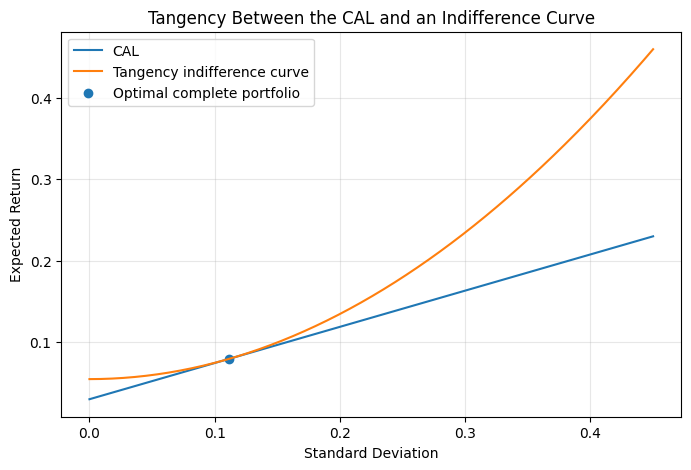

Optimal risky-portfolio weight: 61.73%
Optimal expected return: 7.94%
Optimal standard deviation: 11.11%


In [16]:
A = 4
y_opt = (mu_risky - Rf) / (A * sigma_risky**2)
sigma_opt = y_opt * sigma_risky
mu_opt = Rf + y_opt * (mu_risky - Rf)
U_opt = mu_opt - 0.5 * A * sigma_opt**2

sigma_grid = np.linspace(0, 0.45, 300)
cal_mu = Rf + ((mu_risky - Rf) / sigma_risky) * sigma_grid
indiff_mu = U_opt + 0.5 * A * sigma_grid**2

plt.figure(figsize=(8, 5))
plt.plot(sigma_grid, cal_mu, label="CAL")
plt.plot(sigma_grid, indiff_mu, label="Tangency indifference curve")
plt.scatter([sigma_opt], [mu_opt], label="Optimal complete portfolio")
plt.title("Tangency Between the CAL and an Indifference Curve")
plt.xlabel("Standard Deviation")
plt.ylabel("Expected Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal risky-portfolio weight: {y_opt:.2%}")
print(f"Optimal expected return: {mu_opt:.2%}")
print(f"Optimal standard deviation: {sigma_opt:.2%}")

This graph combines the two sides of portfolio theory.

The CAL is the market opportunity set. The indifference curve is the investor's preference map. Their tangency gives the optimal portfolio for that investor.

## 15. Leverage and the CAL When Borrowing Is Possible at the Risk-Free Rate

If the investor chooses \( y>1 \), the investor borrows \( y-1 \) at the risk-free rate and invests more than 100% of wealth in the risky portfolio.

For example, if \( y=1.50 \), the investor invests 150% of wealth in the risky portfolio and finances the extra 50% by borrowing.

The expected return is:

$$
\mathbb{E}[R_c] = R_f + y(\mathbb{E}[R_P]-R_f).
$$

The standard deviation is:

$$
\sigma_c = y\sigma_P.
$$

When borrowing and lending occur at the same risk-free rate, the CAL remains a straight line.

In [17]:
weights = np.array([0, 0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 2.00])
leverage_table = pd.DataFrame({
    "Weight in Risky Portfolio": weights,
    "Borrowing/Lending Position": 1 - weights,
    "Expected Return": Rf + weights * (mu_risky - Rf),
    "Standard Deviation": weights * sigma_risky
})
leverage_table

,Weight in Risky Portfolio,Borrowing/Lending Position,Expected Return,Standard Deviation
0,0.00,1.00,0.03,0.000
1,0.25,0.75,0.05,0.045
2,0.50,0.50,0.07,0.090
3,0.75,0.25,0.09,0.135
4,1.00,0.00,0.11,0.180
5,1.25,-0.25,0.13,0.225
6,1.50,-0.50,0.15,0.270
7,2.00,-1.00,0.19,0.360


A negative risk-free weight means the investor borrows. A positive risk-free weight means the investor lends.

## 16. Leverage When the Borrowing Rate Exceeds the Lending Rate

In practice, investors usually cannot borrow at the same rate at which they lend.

Let:

- \( R_f^L \) be the lending rate,
- \( R_f^B \) be the borrowing rate,
- \( R_f^B > R_f^L \).

For \( 0 \leq y \leq 1 \), the investor lends at \( R_f^L \):

$$
\mathbb{E}[R_c] = R_f^L + y(\mathbb{E}[R_P]-R_f^L).
$$

For \( y > 1 \), the investor borrows at \( R_f^B \):

$$
\mathbb{E}[R_c] = R_f^B + y(\mathbb{E}[R_P]-R_f^B).
$$

The CAL becomes kinked at \( y=1 \). The slope is lower beyond the kink because borrowing is expensive.

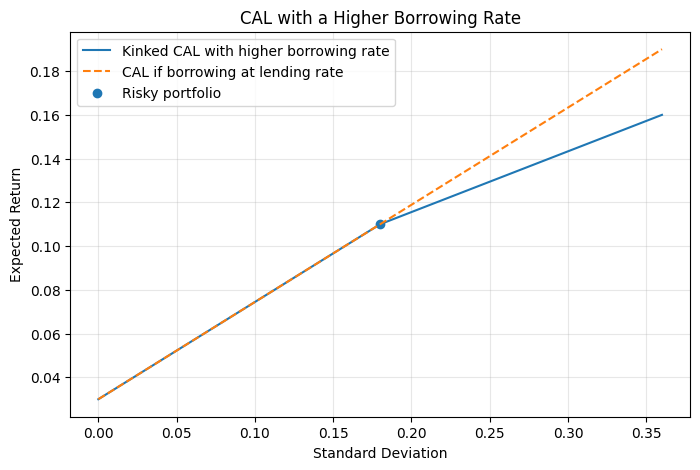

In [18]:
Rf_lend = 0.03
Rf_borrow = 0.06
y_grid = np.linspace(0, 2.0, 300)

mu_kinked = np.where(
    y_grid <= 1,
    Rf_lend + y_grid * (mu_risky - Rf_lend),
    Rf_borrow + y_grid * (mu_risky - Rf_borrow)
)
sigma_kinked = y_grid * sigma_risky

mu_straight = Rf_lend + y_grid * (mu_risky - Rf_lend)

plt.figure(figsize=(8, 5))
plt.plot(sigma_kinked, mu_kinked, label="Kinked CAL with higher borrowing rate")
plt.plot(sigma_kinked, mu_straight, linestyle="--", label="CAL if borrowing at lending rate")
plt.scatter([sigma_risky], [mu_risky], label="Risky portfolio")
plt.title("CAL with a Higher Borrowing Rate")
plt.xlabel("Standard Deviation")
plt.ylabel("Expected Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The higher borrowing rate penalizes leverage. The investor can still lever the risky portfolio, but the reward for taking additional risk is lower beyond the point where borrowing begins.

## 17. Finding the Optimal Allocation with a Higher Borrowing Rate

With a kinked CAL, the optimal allocation may occur:

1. On the lending segment,
2. At the kink \( y=1 \),
3. On the borrowing segment.

A simple way to solve the problem is to compute utility over a grid of possible risky-portfolio weights and choose the maximum.

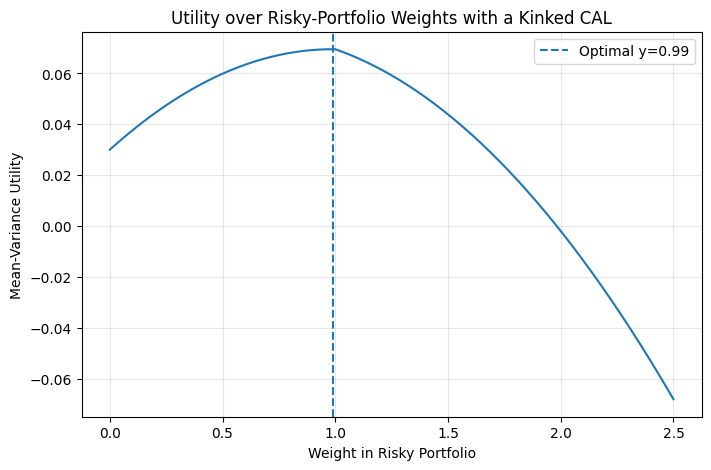

,Risk Aversion A,Optimal Weight in Risky Portfolio,Expected Return,Standard Deviation,Utility
0,2.5,0.99,0.1092,0.1782,0.069506


In [19]:
def mv_utility(mu, sigma, A):
    return mu - 0.5 * A * sigma**2

A = 2.5
y_grid = np.linspace(0, 2.5, 501)
mu_kinked = np.where(
    y_grid <= 1,
    Rf_lend + y_grid * (mu_risky - Rf_lend),
    Rf_borrow + y_grid * (mu_risky - Rf_borrow)
)
sigma_kinked = y_grid * sigma_risky
utility_kinked = mv_utility(mu_kinked, sigma_kinked, A)

best_idx = np.argmax(utility_kinked)
best_y = y_grid[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(y_grid, utility_kinked)
plt.axvline(best_y, linestyle="--", label=f"Optimal y={best_y:.2f}")
plt.title("Utility over Risky-Portfolio Weights with a Kinked CAL")
plt.xlabel("Weight in Risky Portfolio")
plt.ylabel("Mean-Variance Utility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

pd.DataFrame([{
    "Risk Aversion A": A,
    "Optimal Weight in Risky Portfolio": best_y,
    "Expected Return": mu_kinked[best_idx],
    "Standard Deviation": sigma_kinked[best_idx],
    "Utility": utility_kinked[best_idx]
}])

The kinked borrowing condition is more realistic than the textbook case. It also explains why even optimistic investors may choose not to use much leverage when borrowing costs are high.

## 18. Risky Portfolio Choice: The Tangency Portfolio

So far, we assumed a single risky portfolio. But investors usually face many risky assets.

If all investors have access to the same risky assets and can borrow and lend at the same risk-free rate, the risky portfolio they prefer is the portfolio with the highest Sharpe ratio.

This is called the **tangency portfolio**.

Let:

- \( \mu \) be the vector of expected returns,
- \( R_f \) be the risk-free rate,
- \( \Sigma \) be the covariance matrix.

The tangency portfolio has weights proportional to:

$$
w_T \propto \Sigma^{-1}(\mu - R_f \mathbf{1}).
$$

The weights are then scaled so that:

$$
\mathbf{1}'w_T = 1.
$$

The tangency portfolio is the risky portfolio that generates the steepest CAL.

In [20]:
# Construct a simple tangency portfolio from four risky assets
asset_names = ["Stocks", "Bonds", "REITs", "Commodities"]
mu = np.array([0.10, 0.05, 0.08, 0.07])
vol = np.array([0.18, 0.07, 0.15, 0.20])
corr = np.array([
    [1.00, 0.10, 0.55, 0.25],
    [0.10, 1.00, 0.20, -0.05],
    [0.55, 0.20, 1.00, 0.30],
    [0.25, -0.05, 0.30, 1.00]
])
Sigma = np.outer(vol, vol) * corr
ones = np.ones(len(mu))

excess = mu - Rf * ones
raw_weights = np.linalg.inv(Sigma) @ excess
tangency_weights = raw_weights / np.sum(raw_weights)

tangency_mu = tangency_weights @ mu
tangency_sigma = np.sqrt(tangency_weights @ Sigma @ tangency_weights)
tangency_sharpe = (tangency_mu - Rf) / tangency_sigma

tangency_table = pd.DataFrame({
    "Asset": asset_names,
    "Tangency Portfolio Weight": tangency_weights
})
display(tangency_table)

print(f"Tangency expected return: {tangency_mu:.2%}")
print(f"Tangency standard deviation: {tangency_sigma:.2%}")
print(f"Tangency Sharpe ratio: {tangency_sharpe:.2f}")

,Asset,Tangency Portfolio Weight
0,Stocks,0.252475
1,Bonds,0.557042
2,REITs,0.100358
3,Commodities,0.090125


Tangency expected return: 6.74%
Tangency standard deviation: 7.73%
Tangency Sharpe ratio: 0.48


The tangency portfolio can include negative weights if short-selling is allowed. In practice, portfolio constraints often limit short positions, leverage, illiquid assets, concentrated exposures, and turnover. Those constraints can move the practical portfolio away from the unconstrained mathematical tangency portfolio.

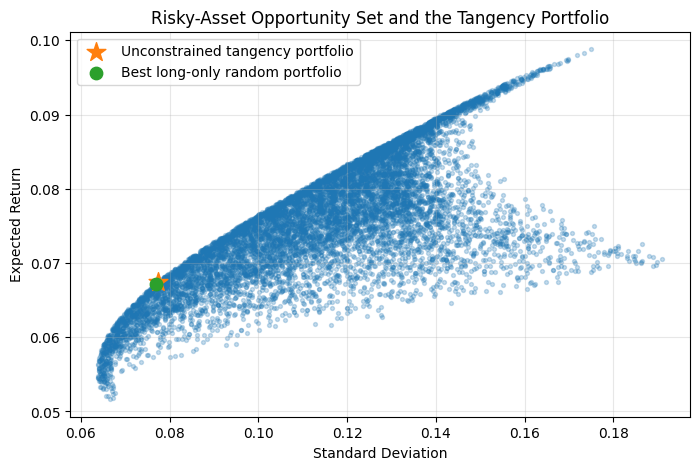

In [21]:
# Random portfolios to visualize the opportunity set and tangency portfolio
num_ports = 10000
random_weights = rng.dirichlet(np.ones(len(mu)), size=num_ports)
port_mu = random_weights @ mu
port_sigma = np.sqrt(np.einsum("ij,jk,ik->i", random_weights, Sigma, random_weights))
port_sharpe = (port_mu - Rf) / port_sigma

best_random_idx = np.argmax(port_sharpe)

plt.figure(figsize=(8, 5))
plt.scatter(port_sigma, port_mu, s=8, alpha=0.25)
plt.scatter([tangency_sigma], [tangency_mu], marker="*", s=200, label="Unconstrained tangency portfolio")
plt.scatter([port_sigma[best_random_idx]], [port_mu[best_random_idx]], marker="o", s=80, label="Best long-only random portfolio")
plt.title("Risky-Asset Opportunity Set and the Tangency Portfolio")
plt.xlabel("Standard Deviation")
plt.ylabel("Expected Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The cloud shows long-only portfolios. The unconstrained tangency portfolio may lie outside that cloud if it uses short positions. The best feasible portfolio depends on the constraints imposed on the investor.

## 19. The Mutual Fund Separation Result

In the classical mean-variance model with a risk-free asset, portfolio choice separates into two decisions.

First, choose the best risky portfolio. This is the tangency portfolio.

Second, decide how much to allocate to that tangency portfolio versus the risk-free asset.

The first decision is about investment opportunities. The second is about investor risk aversion.

All investors with the same beliefs and access to the same assets hold the same risky tangency portfolio. Conservative investors hold more risk-free assets. Aggressive investors hold more of the tangency portfolio, possibly using leverage.

This is called a separation result.

## 20. The Market Portfolio and the Diversified Passive Strategy

In equilibrium, if all investors hold the same tangency portfolio of risky assets, then the aggregate risky portfolio held by investors must be the market portfolio.

The **market portfolio** is the value-weighted portfolio of all risky assets.

This gives the logic for diversified passive investing:

1. If markets are competitive,
2. if investors share similar information,
3. if investors can diversify cheaply,
4. and if the market portfolio is mean-variance efficient,

then a broad value-weighted index fund is a natural risky portfolio.

The investor then chooses how much to allocate to the market portfolio and how much to allocate to the risk-free asset.

## 21. The Capital Market Line

The **capital market line**, or CML, is the CAL formed using the market portfolio as the risky portfolio.

Let \( M \) denote the market portfolio. Then:

$$
\mathbb{E}[R_c]
=
R_f
+
\frac{\mathbb{E}[R_M]-R_f}{\sigma_M}
\sigma_c.
$$

The slope is the market Sharpe ratio:

$$
S_M =
\frac{\mathbb{E}[R_M]-R_f}{\sigma_M}.
$$

The CML applies to efficient complete portfolios formed from the risk-free asset and the market portfolio.

It should not be confused with the security market line. The CML relates expected return to total standard deviation for efficient portfolios. The security market line relates expected return to beta for individual assets and portfolios.

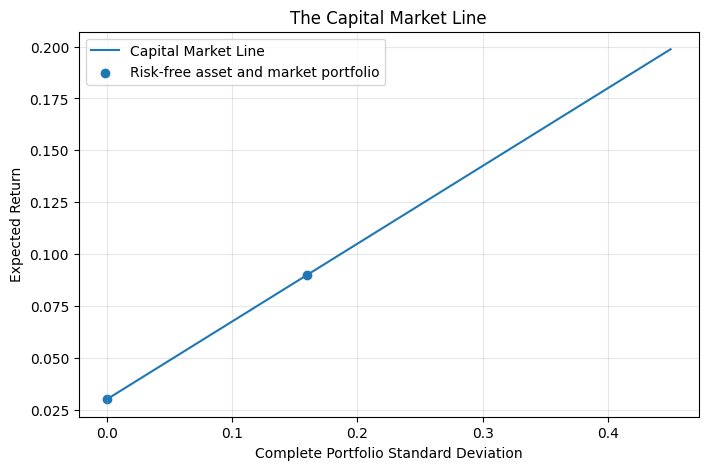

Market Sharpe ratio: 0.38


In [22]:
market_mu = 0.09
market_sigma = 0.16
market_sharpe = (market_mu - Rf) / market_sigma

sigma_grid = np.linspace(0, 0.45, 300)
cml_mu = Rf + market_sharpe * sigma_grid

plt.figure(figsize=(8, 5))
plt.plot(sigma_grid, cml_mu, label="Capital Market Line")
plt.scatter([0, market_sigma], [Rf, market_mu], label="Risk-free asset and market portfolio")
plt.title("The Capital Market Line")
plt.xlabel("Complete Portfolio Standard Deviation")
plt.ylabel("Expected Return")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Market Sharpe ratio: {market_sharpe:.2f}")

The CML says that efficient investors differ mainly in how far they move along the same line.

Very risk-averse investors choose a point near the risk-free asset. Less risk-averse investors choose a point closer to or beyond the market portfolio.

## 22. Inferring the Typical Investor's Risk Aversion

Because investors allocate according to risk aversion, we can invert the optimal allocation formula.

Recall:

$$
y^*
=
\frac{\mathbb{E}[R_M]-R_f}{A\sigma_M^2}.
$$

If the representative investor holds the market portfolio as the aggregate risky portfolio and has \( y^* = 1 \), then:

$$
1 =
\frac{\mathbb{E}[R_M]-R_f}{A\sigma_M^2}.
$$

Therefore:

$$
A =
\frac{\mathbb{E}[R_M]-R_f}{\sigma_M^2}.
$$

This gives an implied representative risk-aversion coefficient.

For example, if the expected market excess return is 6% and market volatility is 16%, then:

$$
A = \frac{0.06}{0.16^2}.
$$

$$
A = \frac{0.06}{0.0256} \approx 2.34.
$$

In [23]:
market_excess_return = 0.06
market_volatility = 0.16
implied_A = market_excess_return / market_volatility**2
implied_A

2.34375

This is a stylized calculation, not a literal measurement of every person's preferences. The observed market reflects heterogeneous investors, institutions, leverage constraints, taxes, labor income risk, beliefs, regulations, and market frictions.

Still, the calculation is useful because it ties observed market prices to the risk-bearing preferences required to hold the aggregate risky portfolio.

In [24]:
# Sensitivity of implied risk aversion to market excess return and volatility
excess_returns = np.linspace(0.03, 0.09, 7)
volatilities = np.linspace(0.10, 0.25, 7)

sensitivity = pd.DataFrame(
    index=[f"{v:.0%}" for v in volatilities],
    columns=[f"{er:.0%}" for er in excess_returns],
    dtype=float
)

for v in volatilities:
    for er in excess_returns:
        sensitivity.loc[f"{v:.0%}", f"{er:.0%}"] = er / v**2

sensitivity

,3%,4%,5%,6%,7%,8%,9%
10%,3.000000,4.000000,5.000000,6.000000,7.000000,8.000000,9.000000
12%,1.920000,2.560000,3.200000,3.840000,4.480000,5.120000,5.760000
15%,1.333333,1.777778,2.222222,2.666667,3.111111,3.555556,4.000000
18%,0.979592,1.306122,1.632653,1.959184,2.285714,2.612245,2.938776
20%,0.750000,1.000000,1.250000,1.500000,1.750000,2.000000,2.250000
22%,0.592593,0.790123,0.987654,1.185185,1.382716,1.580247,1.777778
25%,0.480000,0.640000,0.800000,0.960000,1.120000,1.280000,1.440000


The implied risk-aversion estimate rises when the assumed equity risk premium rises and falls when the assumed market variance rises.

The formula is simple:

$$
A = \frac{\text{market risk premium}}{\text{market variance}}.
$$

A high risk premium relative to variance implies high representative risk aversion or other market frictions that make risky assets require substantial compensation.

## 23. A Complete Numerical Example

Suppose:

- Risk-free rate: \( R_f = 3\% \),
- Market expected return: \( \mathbb{E}[R_M] = 9\% \),
- Market standard deviation: \( \sigma_M = 16\% \),
- Investor risk aversion: \( A = 4 \).

The investor's optimal allocation to the market portfolio is:

$$
y^*
=
\frac{0.09-0.03}{4(0.16)^2}.
$$

$$
y^*
=
\frac{0.06}{4(0.0256)}
=
\frac{0.06}{0.1024}
\approx 0.586.
$$

The investor places about 58.6% in the market portfolio and 41.4% in the risk-free asset.

The expected complete-portfolio return is:

$$
\mathbb{E}[R_c]
=
0.03 + 0.586(0.06)
\approx 6.52\%.
$$

The complete-portfolio standard deviation is:

$$
\sigma_c = 0.586(0.16) \approx 9.38\%.
$$

In [25]:
Rf = 0.03
mu_M = 0.09
sigma_M = 0.16
A = 4

y_star = (mu_M - Rf) / (A * sigma_M**2)
mu_c = Rf + y_star * (mu_M - Rf)
sigma_c = y_star * sigma_M
U_c = mu_c - 0.5 * A * sigma_c**2

pd.DataFrame([{
    "Risk-Free Rate": Rf,
    "Market Expected Return": mu_M,
    "Market Standard Deviation": sigma_M,
    "Risk Aversion A": A,
    "Optimal Market Weight": y_star,
    "Risk-Free Weight": 1 - y_star,
    "Complete Portfolio Expected Return": mu_c,
    "Complete Portfolio Standard Deviation": sigma_c,
    "Mean-Variance Utility": U_c
}])

,Risk-Free Rate,Market Expected Return,Market Standard Deviation,Risk Aversion A,Optimal Market Weight,Risk-Free Weight,Complete Portfolio Expected Return,Complete Portfolio Standard Deviation,Mean-Variance Utility
0,0.03,0.09,0.16,4,0.585938,0.414062,0.065156,0.09375,0.047578


This example shows the full logic of the lecture.

The market offers a tradeoff between expected return and risk. The investor's risk aversion determines how much of that tradeoff the investor wants to accept.

## 24. Monte Carlo Demonstration of Utility-Based Portfolio Choice

We can also simulate returns and evaluate expected utility directly.

Suppose an investor has initial wealth \( W_0 \), allocates weight \( y \) to a risky asset, and the rest to the risk-free asset.

Terminal wealth is:

$$
W_1 = W_0(1 + R_c).
$$

The complete portfolio return is:

$$
R_c = yR_r + (1-y)R_f.
$$

For CRRA utility, we can compute:

$$
\mathbb{E}[u(W_1)]
$$

for different values of \( y \), and choose the best one.

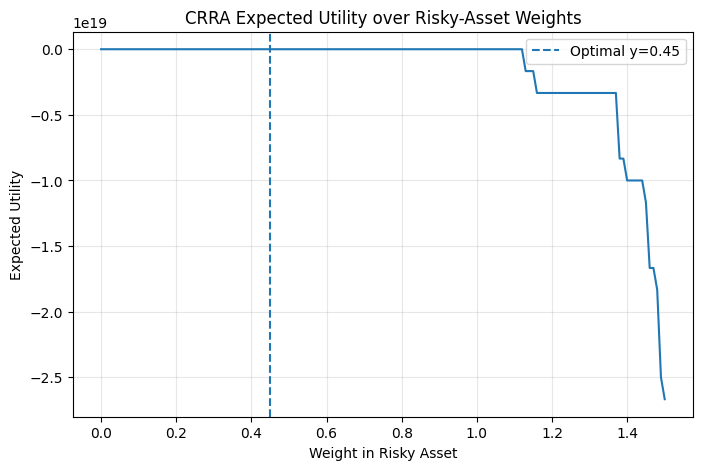

Optimal risky-asset weight from simulation: 45.00%


In [26]:
# Monte Carlo utility maximization using CRRA utility
W0 = 100
Rf = 0.03
mu_r = 0.10
sigma_r = 0.20
gamma = 4
n_sims = 200_000

risky_returns = rng.normal(mu_r, sigma_r, size=n_sims)

y_grid = np.linspace(0, 1.5, 151)
expected_utility = []

for y in y_grid:
    portfolio_returns = y * risky_returns + (1 - y) * Rf
    terminal_wealth = W0 * (1 + portfolio_returns)
    # Avoid utility problems if simulated wealth is non-positive
    terminal_wealth = np.maximum(terminal_wealth, 1e-8)
    expected_utility.append(np.mean(U_crra(terminal_wealth, gamma)))

expected_utility = np.array(expected_utility)
best_idx = np.argmax(expected_utility)

plt.figure(figsize=(8, 5))
plt.plot(y_grid, expected_utility)
plt.axvline(y_grid[best_idx], linestyle="--", label=f"Optimal y={y_grid[best_idx]:.2f}")
plt.title("CRRA Expected Utility over Risky-Asset Weights")
plt.xlabel("Weight in Risky Asset")
plt.ylabel("Expected Utility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal risky-asset weight from simulation: {y_grid[best_idx]:.2%}")

The simulation solves the same economic problem but does not rely on mean-variance utility. It evaluates expected utility directly.

In more advanced applications, this approach can be extended to non-normal returns, borrowing constraints, taxes, labor income risk, background risks, and multi-period portfolio choice.

## 25. Summary of Key Formulas

### Expected Utility

$$
\mathbb{E}[U(W_1)].
$$

### CRRA Utility

$$
u(W) = \frac{W^{1-\gamma}}{1-\gamma},
\quad \gamma \neq 1.
$$

### Log Utility

$$
u(W)=\ln(W).
$$

### CARA Utility

$$
u(W)=-e^{-aW}.
$$

### Certainty Equivalent

$$
U(CE)=\mathbb{E}[U(W_1)].
$$

### Mean-Variance Utility

$$
U = \mathbb{E}[R] - \frac{A}{2}\sigma^2.
$$

### Portfolio Expected Return

$$
\mu_p = w'\mu.
$$

### Portfolio Variance

$$
\sigma_p^2 = w'\Sigma w.
$$

### Capital Allocation Line

$$
\mathbb{E}[R_c]
=
R_f
+
\frac{\mathbb{E}[R_P]-R_f}{\sigma_P}
\sigma_c.
$$

### Sharpe Ratio

$$
S_P = \frac{\mathbb{E}[R_P]-R_f}{\sigma_P}.
$$

### Optimal Risky Weight

$$
y^*
=
\frac{\mathbb{E}[R_P]-R_f}{A\sigma_P^2}.
$$

### Tangency Portfolio

$$
w_T \propto \Sigma^{-1}(\mu - R_f\mathbf{1}).
$$

### Capital Market Line

$$
\mathbb{E}[R_c]
=
R_f
+
\frac{\mathbb{E}[R_M]-R_f}{\sigma_M}
\sigma_c.
$$

### Implied Representative Risk Aversion

$$
A =
\frac{\mathbb{E}[R_M]-R_f}{\sigma_M^2}.
$$

## 26. Conceptual Takeaways

1. Risk aversion means investors dislike uncertainty in wealth because marginal utility declines with wealth.

2. Different utility functions impose different assumptions about how risk tolerance changes with wealth.

3. Certainty equivalents translate risky payoffs into sure-payoff equivalents.

4. Mean-variance utility is a powerful simplified framework for connecting expected return, risk, and investor preferences.

5. Portfolio expected return is linear in weights, but portfolio variance depends on covariance.

6. The risk-free asset turns the risky-asset opportunity set into a straight capital allocation line.

7. The Sharpe ratio is the slope of the capital allocation line.

8. The optimal risky-asset weight rises with the risk premium and falls with risk aversion and variance.

9. If borrowing is more expensive than lending, the CAL becomes kinked and leverage is less attractive.

10. The tangency portfolio is the risky portfolio with the highest Sharpe ratio.

11. In equilibrium, the market portfolio plays the role of the aggregate tangency portfolio.

12. The capital market line describes efficient complete portfolios formed from the risk-free asset and the market portfolio.

13. Observed market risk premia and volatility can be used to infer a stylized representative risk-aversion parameter.